In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


In [62]:
STOCK = "AAPL"
MARKET = "SPY"

TICKERS = [STOCK, MARKET]
START_DATE = "2015-01-01"
# END_DATE = "2024-12-31"
END_DATE = None  # до сьогодні




In [63]:
df = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    group_by="ticker",
    auto_adjust=True,
    progress=False
)

In [64]:
df.head()

Ticker             SPY                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2015-01-02  171.378523  171.793724  169.551627  170.589630  121465900   
2015-01-05  169.543303  169.709381  167.201575  167.508820  169632600   
2015-01-06  167.816035  168.339192  165.133838  165.931030  209151400   
2015-01-07  167.259737  168.339263  166.811325  167.998795  125346700   
2015-01-08  169.410459  171.195832  169.393860  170.979919  147217800   

Ticker           AAPL                                              
Price            Open       High        Low      Close     Volume  
Date                                                               
2015-01-02  24.694227  24.705313  23.798593  24.237543  212818400  
2015-01-05  24.006996  24.086805  23.368524  23.554745  257142000  
2015-01-06  23.619040  23.816346  23.195608  23.556967  263188400  
2015-01-07  23.765343  23.987034  23.654497  23.887274  160423600  
2015-01-08  24.215383  24.862723  24.097885  24.805082  237458000

In [66]:
df.columns

MultiIndex([( 'SPY',   'Open'),
            ( 'SPY',   'High'),
            ( 'SPY',    'Low'),
            ( 'SPY',  'Close'),
            ( 'SPY', 'Volume'),
            ('AAPL',   'Open'),
            ('AAPL',   'High'),
            ('AAPL',    'Low'),
            ('AAPL',  'Close'),
            ('AAPL', 'Volume')],
           names=['Ticker', 'Price'])

In [67]:
df.index.name = "Date"
df = df.sort_index()

In [68]:
df.isna().sum()

Ticker  Price 
SPY     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
AAPL    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
dtype: int64

In [69]:
# Базові returns
returns = df.xs("Close", level=1, axis=1).pct_change()

returns.columns = pd.MultiIndex.from_product(
    [returns.columns, ["return"]]
)

returns.head()

Ticker,SPY,AAPL
,return,return
Date,,
2015-01-02,NaN,NaN
2015-01-05,-0.018060,-0.028171
2015-01-06,-0.009419,0.000094
2015-01-07,0.012462,0.014022
2015-01-08,0.017745,0.038422


In [70]:
df = pd.concat([df, returns], axis=1)
df.head()

Ticker             SPY                                                 \
                  Open        High         Low       Close     Volume   
Date                                                                    
2015-01-02  171.378523  171.793724  169.551627  170.589630  121465900   
2015-01-05  169.543303  169.709381  167.201575  167.508820  169632600   
2015-01-06  167.816035  168.339192  165.133838  165.931030  209151400   
2015-01-07  167.259737  168.339263  166.811325  167.998795  125346700   
2015-01-08  169.410459  171.195832  169.393860  170.979919  147217800   

Ticker           AAPL                                                   SPY  \
                 Open       High        Low      Close     Volume    return   
Date                                                                          
2015-01-02  24.694227  24.705313  23.798593  24.237543  212818400       NaN   
2015-01-05  24.006996  24.086805  23.368524  23.554745  257142000 -0.018060   
2015-01-06  23.619040  23.816346  23.195608  23.556967  263188400 -0.009419   
2015-01-07  23.765343  23.987034  23.654497  23.887274  160423600  0.012462   
2015-01-08  24.215383  24.862723  24.097885  24.805082  237458000  0.017745   

Ticker          AAPL  
              return  
Date                  
2015-01-02       NaN  
2015-01-05 -0.028171  
2015-01-06  0.000094  
2015-01-07  0.014022  
2015-01-08  0.038422

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2772 entries, 2015-01-02 to 2026-01-09
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (SPY, Open)     2772 non-null   float64
 1   (SPY, High)     2772 non-null   float64
 2   (SPY, Low)      2772 non-null   float64
 3   (SPY, Close)    2772 non-null   float64
 4   (SPY, Volume)   2772 non-null   int64  
 5   (AAPL, Open)    2772 non-null   float64
 6   (AAPL, High)    2772 non-null   float64
 7   (AAPL, Low)     2772 non-null   float64
 8   (AAPL, Close)   2772 non-null   float64
 9   (AAPL, Volume)  2772 non-null   int64  
 10  (SPY, return)   2771 non-null   float64
 11  (AAPL, return)  2771 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 281.5 KB


In [72]:
df.isna().sum()

Ticker        
SPY     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
AAPL    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
SPY     return    1
AAPL    return    1
dtype: int64

In [73]:
df.describe()

Ticker          SPY                                                       \
               Open         High          Low        Close        Volume   
count   2772.000000  2772.000000  2772.000000  2772.000000  2.772000e+03   
mean     338.633437   340.462988   336.634416   338.691583  8.605716e+07   
std      141.504557   142.170363   140.738680   141.523440  4.388224e+07   
min      154.540157   156.031833   152.881578   154.980881  2.027000e+07   
25%      219.272431   220.497218   218.220202   219.570843  5.877918e+07   
50%      301.318173   303.097596   299.450364   301.135742  7.570650e+07   
75%      423.691401   425.754486   421.312781   423.708817  9.927042e+07   
max      692.190002   695.309998   689.320007   694.070007  5.072443e+08   

Ticker         AAPL                                                       \
               Open         High          Low        Close        Volume   
count   2772.000000  2772.000000  2772.000000  2772.000000  2.772000e+03   
mean     106.571499   107.723488   105.505150   106.664278  1.112573e+08   
std       74.528211    75.313086    73.813882    74.598349  6.803763e+07   
min       20.526539    20.907420    20.405658    20.604080  1.791060e+07   
25%       36.737348    37.131065    36.343561    36.679013  6.477780e+07   
50%       89.466786    90.716903    88.751392    89.950584  9.449160e+07   
75%      168.563844   170.529221   167.311463   168.726334  1.372580e+08   
max      286.200012   288.619995   283.299988   286.190002  6.488252e+08   

Ticker          SPY         AAPL  
             return       return  
count   2771.000000  2771.000000  
mean       0.000569     0.001020  
std        0.011198     0.018159  
min       -0.109424    -0.128647  
25%       -0.003687    -0.007315  
50%        0.000652     0.000941  
75%        0.005930     0.009904  
max        0.105019     0.153289

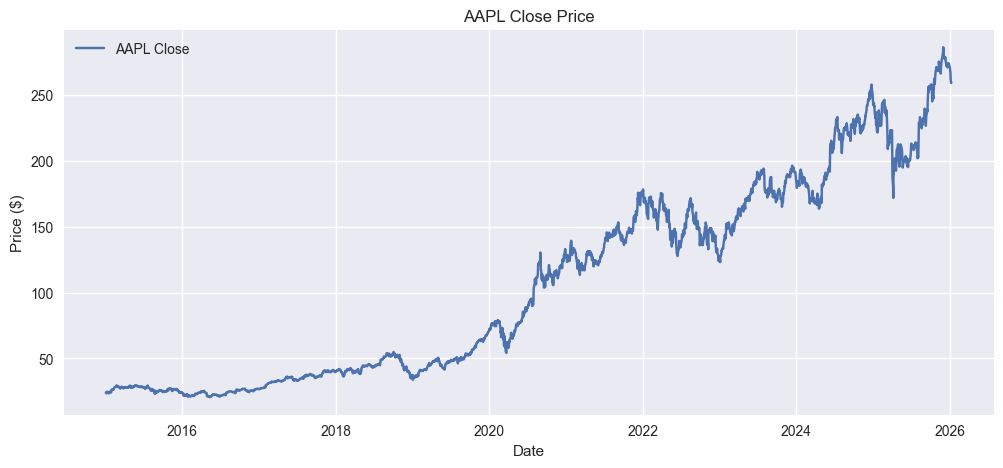

In [79]:
# Візуалізація ціни
TICKER = STOCK

plt.figure(figsize=(12, 5))
plt.plot(
    df.index,
    df[(TICKER, "Close")],
    label=f"{TICKER} Close"
)
plt.title(f"{TICKER} Close Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

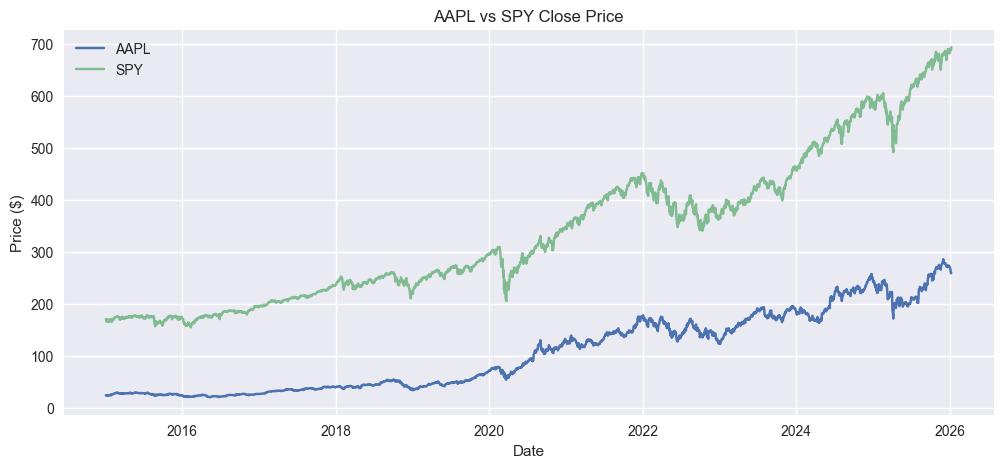

In [80]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df[("AAPL", "Close")], label="AAPL")
plt.plot(df.index, df[("SPY",  "Close")], label="SPY", alpha=0.7)

plt.title("AAPL vs SPY Close Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

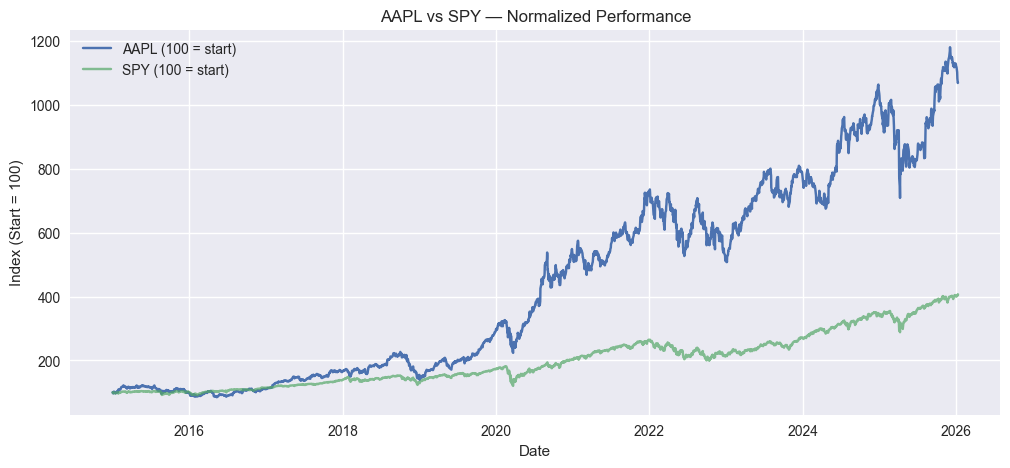

In [82]:
norm_aapl = df[("AAPL", "Close")] / df[("AAPL", "Close")].iloc[0] * 100
norm_spy  = df[("SPY",  "Close")] / df[("SPY",  "Close")].iloc[0] * 100

plt.figure(figsize=(12, 5))

plt.plot(df.index, norm_aapl, label="AAPL (100 = start)")
plt.plot(df.index, norm_spy,  label="SPY (100 = start)", alpha=0.7)

plt.title("AAPL vs SPY — Normalized Performance")
plt.xlabel("Date")
plt.ylabel("Index (Start = 100)")
plt.legend()
plt.grid(True)
plt.show()




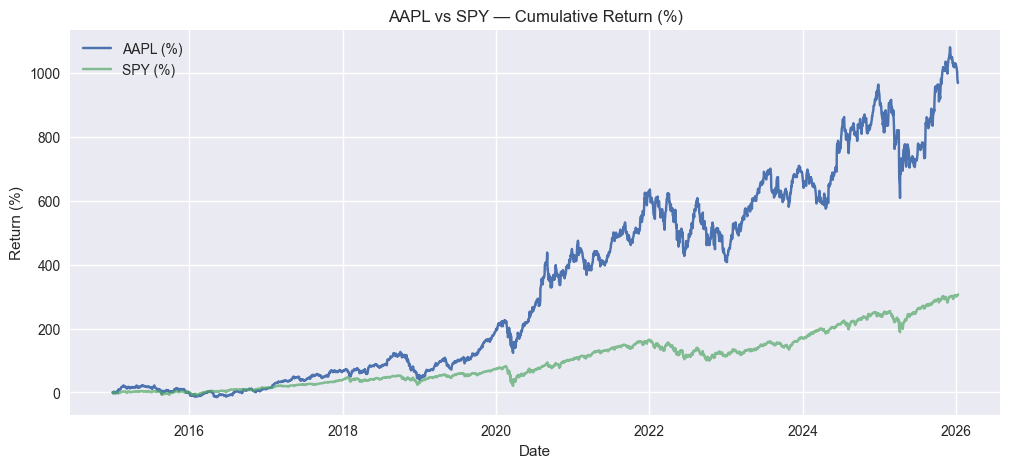

In [84]:
cumret_aapl = (df[("AAPL", "Close")] / df[("AAPL", "Close")].iloc[0] - 1) * 100
cumret_spy  = (df[("SPY",  "Close")] / df[("SPY",  "Close")].iloc[0] - 1) * 100

plt.figure(figsize=(12, 5))

plt.plot(df.index, cumret_aapl, label="AAPL (%)")
plt.plot(df.index, cumret_spy,  label="SPY (%)", alpha=0.7)

plt.title("AAPL vs SPY — Cumulative Return (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.show()


In [180]:
# # Feature Engineering (базовий)
df[(STOCK, "SMA_20")] = df[(STOCK, "Close")].rolling(20).mean()
df[(STOCK, "SMA_50")] = df[(STOCK, "Close")].rolling(50).mean()

ret_stock = df[(STOCK, "Close")].pct_change()
ret_spy   = df[(MARKET,  "Close")].pct_change()

df[(STOCK, "return")] = ret_stock
df[(MARKET,  "return")] = ret_spy

# Relative return
df[(STOCK, "rel_return")] = ret_stock - ret_spy

# Price vs SPY
df[(STOCK, "price_vs_spy")] = (
    df[(STOCK, "Close")] / df[(MARKET, "Close")]
)

# 🔹 Beta (60d)
df[(STOCK, "beta_60d")] = (
    ret_stock.rolling(60).cov(ret_spy) /
    ret_spy.rolling(60).var()
)

# 🔹 Momentum
df[(STOCK, "mom_20")] = df[(STOCK, "Close")].pct_change(20)
df[(MARKET,  "mom_20")] = df[(MARKET,  "Close")].pct_change(20)

df[(STOCK, "rel_mom_20")] = (
    df[(STOCK, "mom_20")] - df[(MARKET, "mom_20")]
)


# df["mom_stock_20"] = df["Close"].pct_change(20)
# df["mom_spy_20"]   = df_spy["Close"].pct_change(20)
# df["rel_mom_20"]   = df["mom_stock_20"] - df["mom_spy_20"]

# Relative features (AAPL vs SPY)
df[(STOCK, "rel_return")] = (
    df[(STOCK, "return")] - df[(MARKET, "return")]
)

# Price ratio
df[(STOCK, "price_vs_spy")] = (
    df[(STOCK, "Close")] / df[(MARKET, "Close")]
)

# Rolling beta (60 днів)
window = 60

cov = (
    df[(STOCK, "return")]
    .rolling(window)
    .cov(df[(MARKET, "return")])
)

var = (
    df[(MARKET, "return")]
    .rolling(window)
    .var()
)

df[(STOCK, "beta_60d")] = cov / var

# Relative momentum
for w in [20, 60]:
    df[(STOCK, f"mom_{w}")] = df[(STOCK, "Close")].pct_change(w)
    df[(MARKET, f"mom_{w}")]  = df[(MARKET, "Close")].pct_change(w)
    df[(STOCK, f"rel_mom_{w}")] = (
        df[(STOCK, f"mom_{w}")] - df[(MARKET, f"mom_{w}")]
    )

In [181]:
df.tail()

Ticker             SPY                                                \
                  Open        High         Low       Close    Volume   
Date                                                                   
2026-01-05  686.539978  689.429993  686.380005  687.719971  71927200   
2026-01-06  687.929993  692.320007  687.780029  691.809998  69273800   
2026-01-07  692.190002  693.960022  689.320007  689.580017  75588300   
2026-01-08  688.820007  690.619995  687.489990  689.510010  64019200   
2026-01-09  690.630005  695.309998  689.179993  694.070007  80049600   

Ticker            AAPL                                                ...  \
                  Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2026-01-05  270.640015  271.510010  266.140015  267.260010  45647200  ...   
2026-01-06  267.000000  267.549988  262.119995  262.359985  52352100  ...   
2026-01-07  263.200012  263.679993  259.809998  260.329987  48309800  ...   
2026-01-08  257.019989  259.290009  255.699997  259.040009  50419300  ...   
2026-01-09  259.079987  260.209991  256.220001  259.369995  39952300  ...   

Ticker                                SPY       AAPL  beta_60d       AAPL  \
           rel_mom_20    mom_60    mom_60 rel_mom_60               RSI_14   
Date                                                                        
2026-01-05  -0.055715  0.036655  0.024724   0.011930  0.785520  25.045369   
2026-01-06  -0.070806  0.033752  0.033813  -0.000062  0.741886  24.243819   
2026-01-07  -0.074875  0.062431  0.059106   0.003324  0.620707  20.665643   
2026-01-08  -0.077900  0.046964  0.042995   0.003969  0.623332  22.003583   
2026-01-09  -0.082061  0.047832  0.051177  -0.003345  0.617775  21.935218   

Ticker                                                      
           Target Target_return Target_up Target_return_5d  
Date                                                        
2026-01-05    NaN           NaN         0              NaN  
2026-01-06    NaN           NaN         0              NaN  
2026-01-07    NaN           NaN         0              NaN  
2026-01-08    NaN           NaN         0              NaN  
2026-01-09    NaN           NaN         0              NaN  

[5 rows x 29 columns]

In [ ]:
# # Flatten для ML (коли треба)
# ml_df = df.copy()
# ml_df.columns = [f"{a}_{b}" for a, b in ml_df.columns]

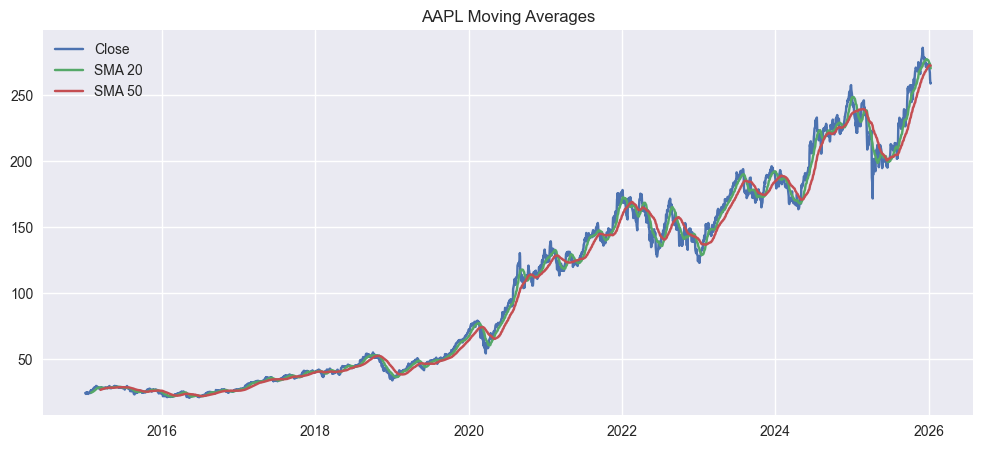

In [91]:
df[(TICKER, "SMA_20")] = df[(TICKER, "Close")].rolling(20).mean()
df[(TICKER, "SMA_50")] = df[(TICKER, "Close")].rolling(50).mean()

plt.figure(figsize=(12, 5))

plt.plot(df.index, df[(TICKER, "Close")], label="Close")
plt.plot(df.index, df[(TICKER, "SMA_20")], label="SMA 20")
plt.plot(df.index, df[(TICKER, "SMA_50")], label="SMA 50")

plt.legend()
plt.title(f"{TICKER} Moving Averages")
plt.show()

In [93]:
# RSI (Relative Strength Index)


def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df[(TICKER, "RSI_14")] = compute_rsi(df[(TICKER, "Close")])

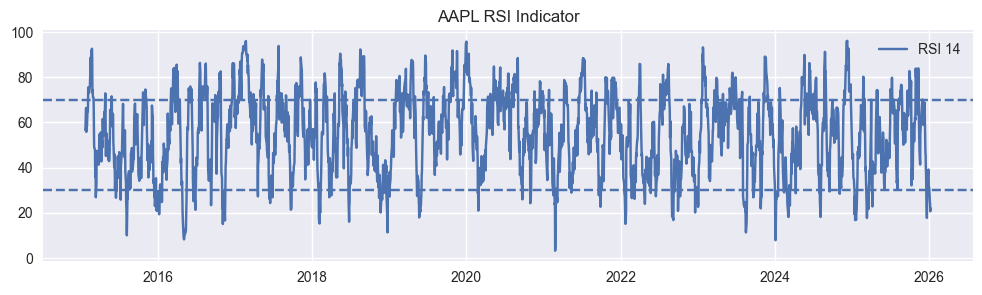

In [94]:
plt.figure(figsize=(12, 3))

plt.plot(df.index, df[(TICKER, "RSI_14")], label="RSI 14")
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title(f"{TICKER} RSI Indicator")
plt.legend()
plt.show()

In [95]:
def col(ticker, name):
    return (ticker, name)

In [162]:
df[col(TICKER, "RSI_14")] = compute_rsi(df[col(TICKER, "Close")])

In [172]:
# Формування датасету для ML

TICKER = "AAPL"
FORECAST_HORIZON = 5

# # Target = ціна через 5 днів.
# df[(TICKER, "Target")] = df[(TICKER, "Close")].shift(-FORECAST_HORIZON)

# # рекомендую (краще для ML) прогноз лог-ретурну
# df[(TICKER, "Target_return")] = (
#     df[(TICKER, "Close")].shift(-FORECAST_HORIZON) /
#     df[(TICKER, "Close")] - 1
# )

# # Варіант B — класифікація (up / down)
# df[(TICKER, "Target_up")] = (
#     df[(TICKER, "Close")].shift(-FORECAST_HORIZON) >
#     df[(TICKER, "Close")]
# ).astype(int)

# Не прогнозувати абсолютну ціну → прогнозувати % зміни / return:
df[(TICKER, "Target_return_5d")] = (
    df[(TICKER, "Close")].shift(-5) / df[(TICKER, "Close")] - 1
)


In [173]:
features = [
    (TICKER, "Close"),
    (TICKER, "SMA_20"),
    (TICKER, "SMA_50"),
    (TICKER, "RSI_14"),
    (TICKER, "Volume"),
]

ml_df = df[features + [(TICKER, "Target")]].dropna()
ml_df.head()


Ticker           AAPL                                                       
                Close     SMA_20     SMA_50     RSI_14     Volume     Target
Date                                                                        
2015-03-16  27.809696  28.424205  26.586999  32.710782  143497200  28.312695
2015-03-17  28.274860  28.415414  26.667746  45.533474  204092400  28.196959
2015-03-18  28.593138  28.412632  26.768514  44.971672  261083600  27.460268
2015-03-19  28.377241  28.402060  26.864919  47.391328  183238000  27.651676
2015-03-20  28.021141  28.361998  26.947596  41.765604  274780400  27.431335

In [174]:
# Train / Test split (по часу!)
split_ratio = 0.8
split_index = int(len(ml_df) * split_ratio)

train_df = ml_df.iloc[:split_index]
test_df = ml_df.iloc[split_index:]

# X — тільки фічі
X_train = train_df[features]
X_test  = test_df[features]

# y — цільова змінна
y_train = train_df[(TICKER, "Target")]
y_test  = test_df[(TICKER, "Target")]

X_train.shape, X_test.shape

# Якщо ти захочеш зробити regression на лог-ретурн або classification, тоді y_train / y_test замінюються на:
# y_train = train_df[(TICKER, "Target_return")]       # регресія
# y_train = train_df[(TICKER, "Target_up")]           # класифікація


((2174, 5), (544, 5))

# Висновки (Markdown cell)
## Висновки

- Дані з Yahoo Finance є повними та придатними для аналізу.
- Історичні ціни демонструють тренди та волатильність.
- Технічні індикатори (SMA, RSI) можуть бути використані як ознаки.
- Дані підготовлено для побудови ML-моделі прогнозування.

In [118]:
df = df_stock.join(df_spy, rsuffix="_spy", how="inner")

NameError: name 'df_stock' is not defined

# Model

In [175]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [176]:
# Train / Test split (по часу, як раніше)
split_ratio = 0.8
split_index = int(len(ml_df) * split_ratio)

train_df = ml_df.iloc[:split_index]
test_df  = ml_df.iloc[split_index:]

X_train = train_df[features]
X_test  = test_df[features]

y_train = train_df[(TICKER, "Target")]
y_test  = test_df[(TICKER, "Target")]

X_train.shape, X_test.shape

((2174, 5), (544, 5))

In [177]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin  = r2_score(y_test, y_pred_lin)

print(f"Linear Regression — MSE: {mse_lin:.2f}, R2: {r2_lin:.3f}")


Linear Regression — MSE: 71.91, R2: 0.916


In [178]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f"Random Forest — MSE: {mse_rf:.2f}, R2: {r2_rf:.3f}")


Random Forest — MSE: 2331.08, R2: -1.716


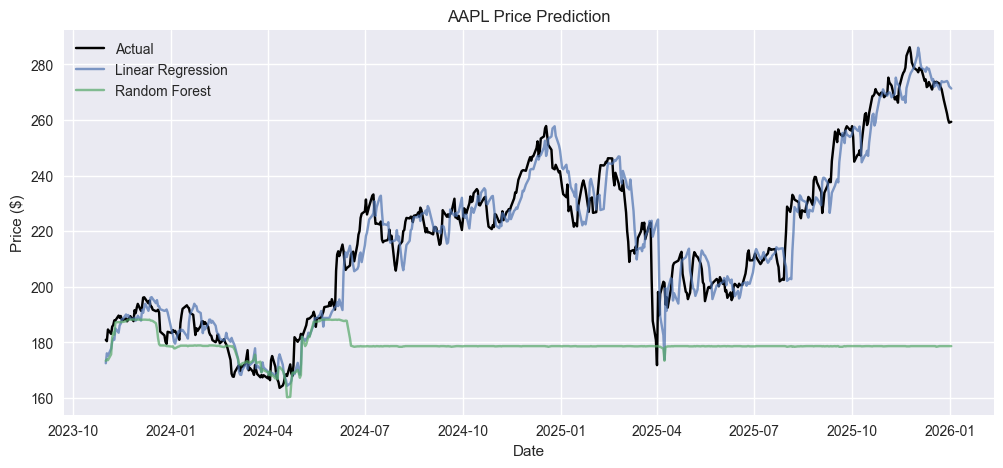

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_df.index, y_test, label="Actual", color="black")
plt.plot(test_df.index, y_pred_lin, label="Linear Regression", alpha=0.7)
plt.plot(test_df.index, y_pred_rf, label="Random Forest", alpha=0.7)
plt.title(f"{TICKER} Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()


Для прогнозування майбутньої ціни акції використано два базові алгоритми: лінійну регресію та Random Forest Regressor. Вхідними ознаками були ціна, SMA 20/50, RSI 14 та обсяг торгівлі. Модель оцінювалась на тестовому наборі за MSE та R². Random Forest показав кращу здатність моделювати нелінійні залежності та ринкову волатильність.

In [ ]:
importances = rf.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")